In [1]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
from collections import defaultdict
import glob
from tqdm import tqdm
import gc
import shutil
import random
from tensorflow.keras.utils import register_keras_serializable

# --- Google Drive Mount and Data Extraction ---
from google.colab import drive
drive.mount('/content/drive')

# Ensure the .tar.gz file exists at this path
print("Extracting dataset...")
!tar -xvzf '/content/drive/MyDrive/OCT2017 (1).tar.gz' -C /content/
print("Dataset extracted.")

Streaming output truncated to the last 5000 lines.
./OCT2017/train/CNV/CNV-6666538-574.jpeg
./OCT2017/train/CNV/CNV-1188386-603.jpeg
./OCT2017/train/CNV/CNV-1781140-74.jpeg
./OCT2017/train/CNV/CNV-7315522-30.jpeg
./OCT2017/train/CNV/CNV-8082730-14.jpeg
./OCT2017/train/CNV/CNV-1781140-180.jpeg
./OCT2017/train/CNV/CNV-7907754-413.jpeg
./OCT2017/train/CNV/CNV-137351-113.jpeg
./OCT2017/train/CNV/CNV-4244160-134.jpeg
./OCT2017/train/CNV/CNV-9642260-283.jpeg
./OCT2017/train/CNV/CNV-732516-169.jpeg
./OCT2017/train/CNV/CNV-2192440-174.jpeg
./OCT2017/train/CNV/CNV-9206459-7.jpeg
./OCT2017/train/CNV/CNV-9598696-112.jpeg
./OCT2017/train/CNV/CNV-1651625-37.jpeg
./OCT2017/train/CNV/CNV-172472-51.jpeg
./OCT2017/train/CNV/CNV-1894770-40.jpeg
./OCT2017/train/CNV/CNV-4612183-53.jpeg
./OCT2017/train/CNV/CNV-9642260-241.jpeg
./OCT2017/train/CNV/CNV-8184974-60.jpeg
./OCT2017/train/CNV/CNV-2158821-4.jpeg
./OCT2017/train/CNV/CNV-9997680-79.jpeg
./OCT2017/train/CNV/CNV-4951152-24.jpeg
./OCT2017/train/CNV/CNV

In [2]:
#@title **SPLITTING DIRECTORY**
import os
import shutil
import random

# === Input Paths ===
test_dir_full = "/content/OCT2017/test"

import os
import shutil
import random
from tqdm import tqdm

# === Set source and target directories ===
original_train_dir = "/content/OCT2017/train"
split_root = "/content/OCT_split"
train_split_dir = os.path.join(split_root, "train")
val_split_dir = os.path.join(split_root, "val")

# === Create target directories ===
os.makedirs(train_split_dir, exist_ok=True)
os.makedirs(val_split_dir, exist_ok=True)

# === Set random seed for reproducibility ===
random.seed(42)

# === Split images for each class ===
SPLIT_RATIO = 0.8  # 80% train, 20% val

for class_name in os.listdir(original_train_dir):
    class_path = os.path.join(original_train_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    split_index = int(len(images) * SPLIT_RATIO)
    train_images = images[:split_index]
    val_images = images[split_index:]

    train_class_dir = os.path.join(train_split_dir, class_name)
    val_class_dir = os.path.join(val_split_dir, class_name)
    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(val_class_dir, exist_ok=True)

    for img_name in tqdm(train_images, desc=f"Train {class_name}"):
        shutil.copy(os.path.join(class_path, img_name), os.path.join(train_class_dir, img_name))

    for img_name in tqdm(val_images, desc=f"Val {class_name}"):
        shutil.copy(os.path.join(class_path, img_name), os.path.join(val_class_dir, img_name))

print("\n✅ Train/Val split complete.")

Val DRUSEN: 100%|██████████| 1724/1724 [00:00<00:00, 8042.91it/s]


✅ Train/Val split complete.


In [3]:
#@title **LOADING**
import tensorflow as tf

# === Paths to subdataset directories ===
train_dir = "/content/OCT_split/train"
val_dir = "/content/OCT_split/val"
test_dir = "/content/OCT2017/test"

# === Hyperparameters ===
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

# === Load Datasets from Folders (in Grayscale) ===
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

# === Extract class names and number of classes ===
class_names = train_ds.class_names
print("Class names:", class_names)
NUM_CLASSES = len(class_names)

# === Convert labels to one-hot ===
def one_hot_encode(image, label):
    return image, tf.one_hot(label, depth=NUM_CLASSES)

# === Apply one-hot encoding ===
train_ds = train_ds.map(one_hot_encode, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(one_hot_encode, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(one_hot_encode, num_parallel_calls=AUTOTUNE)


# === Apply data augmentation to train set only ===
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomRotation(factor=36/360, seed=SEED),
    tf.keras.layers.RandomZoom(height_factor=(-0.2, 0.2), seed=SEED),
    tf.keras.layers.RandomContrast(0.2, seed=SEED)
])

def augment(image, label):
    return data_augmentation(image), label

train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)


# === Prefetch ===
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 66786 files belonging to 4 classes.
Found 16698 files belonging to 4 classes.
Found 1000 files belonging to 4 classes.
Class names: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [4]:
# @title **MODEL**
from tensorflow.keras import regularizers

LEARNING_RATE=0.001
MODEL_SAVE_PATH="new_model_path.keras"
RANDOM_SEED=42
EPOCHS=30
BATCH_SIZE=32

# --- Proposed Custom CNN Model Architecture (from previous turns) ---
# Ensure these are registered for saving/loading the model properly
@register_keras_serializable()
def se_block(input_tensor, reduction_ratio=16):
    channels = input_tensor.shape[-1]
    se = tf.keras.layers.GlobalAveragePooling2D()(input_tensor)
    se = tf.keras.layers.Dense(channels // reduction_ratio, activation='relu')(se)
    se = tf.keras.layers.Dense(channels, activation='sigmoid')(se)
    se = tf.keras.layers.Reshape((1, 1, channels))(se)
    return tf.keras.layers.Multiply()([input_tensor, se])

'''
@register_keras_serializable()
class SpatialAttentionBlock(tf.keras.layers.Layer):
    def __init__(self, kernel_sizes=[1, 3, 7], **kwargs): # Changed to include 3, 5, and 7
        super(SpatialAttentionBlock, self).__init__(**kwargs)
        self.kernel_sizes = kernel_sizes
        self.kernel_initializer = tf.keras.initializers.VarianceScaling()

        # Create a list of Conv2D layers, one for each kernel size
        self.conv2d_layers = []
        for k_size in self.kernel_sizes:
            self.conv2d_layers.append(
                layers.Conv2D(
                    filters=1, # Each branch still outputs a single attention map
                    kernel_size=k_size,
                    strides=(1, 1),
                    padding="same",
                    activation=None, # Sigmoid applied after combining all
                    kernel_initializer=self.kernel_initializer,
                    use_bias=False
                )
            )
        self.concatenate_layer = layers.Concatenate(axis=-1) # For avg/max pool combination

        # No additional layer needed if you are summing the 1-filter outputs.
        # If you were concatenating and then needing to reduce channels, you'd add a 1x1 conv here.
        self.multiply_layer = layers.Multiply()

    # It's good practice to implement a build method for custom layers, especially if
    # weights are dynamically created based on input_shape, or if you want to
    # explicitly define what happens when the layer is built.
    def build(self, input_shape):
        # Your conv2d_layers are already created in __init__ for fixed kernels.
        # If their creation depended on input_shape, they'd go here.
        super(SpatialAttentionBlock, self).build(input_shape)

    def call(self, inputs):
        input_feature = inputs
        avg_pool = tf.reduce_mean(input_feature, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(input_feature, axis=-1, keepdims=True)
        concat = self.concatenate_layer([avg_pool, max_pool]) # Concatenate avg and max pooled features (2 channels)

        # Apply each parallel convolutional layer
        attention_maps_from_branches = []
        for conv_layer in self.conv2d_layers:
            attention_maps_from_branches.append(conv_layer(concat))

        # Combine the attention maps from different kernel sizes
        # Since each branch outputs a single channel (filters=1), summing them is a common
        # and effective way to combine them without increasing channel count.
        if len(attention_maps_from_branches) > 1:
            combined_spatial_attention = tf.add_n(attention_maps_from_branches) # Sum all 1-filter outputs
        else:
            combined_spatial_attention = attention_maps_from_branches[0]


        spatial_attention_map = tf.sigmoid(combined_spatial_attention) # Apply sigmoid for final attention map
        return self.multiply_layer([input_feature, spatial_attention_map])

    def get_config(self):
        config = super(SpatialAttentionBlock, self).get_config()
        config.update({"kernel_sizes": self.kernel_sizes}) # Ensure the list of kernel sizes is saved
        return config
'''
@register_keras_serializable()
def fine_branch(x, filters):
    shortcut = tf.keras.layers.Conv2D(filters, (1, 1), padding='same')(x)
    shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.Conv2D(filters, (1, 1), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([x, shortcut])  # Residual connection
    x = tf.keras.layers.ReLU()(x)

    se_output = se_block(x)
    return se_output

@register_keras_serializable()
def coarse_branch(x, filters):
    shortcut = tf.keras.layers.Conv2D(filters, (1, 1), padding='same')(x)
    shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(filters, (5, 5), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(filters, (7, 7), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([x, shortcut])  # Residual connection
    x = tf.keras.layers.ReLU()(x)

    se_output = se_block(x)
    return se_output

@register_keras_serializable()
def fine_coarse_fusion(x, filters):
    fine = fine_branch(x, filters)
    coarse = coarse_branch(x, filters)
    combined = tf.keras.layers.Concatenate()([fine, coarse])
    combined = tf.keras.layers.Conv2D(filters, (1, 1), padding='same')(combined)
    combined = tf.keras.layers.BatchNormalization()(combined)
    combined = tf.keras.layers.ReLU()(combined)

    res = tf.keras.layers.Conv2D(filters, (1, 1), padding='same')(x)
    res = tf.keras.layers.BatchNormalization()(res)

    return tf.keras.layers.ReLU()(tf.keras.layers.Add()([combined, res]))

@register_keras_serializable()
def build_model(input_shape=(128, 128, 1), num_classes=4):
    input_layer = tf.keras.Input(shape=input_shape)

    # --- Data Augmentation layers (applied only during training) ---
    # The paper mentions resizing images in preprocessing, but also implies that
    # the model itself handles some "variations" if data augmentation is used.
    # Adding a Rescaling layer here to normalize pixel values from 0-255 to 0-1,
    # which is common practice for CNNs.
    x = layers.Rescaling(1./255)(input_layer) # Added for normalization

    '''data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal", seed=RANDOM_SEED), # Changed to "horizontal" only
        layers.RandomRotation(0.1, seed=RANDOM_SEED),
        layers.RandomZoom(height_factor=(-0.2, 0.2), seed=RANDOM_SEED),
        layers.RandomContrast(0.2, seed=RANDOM_SEED)], name="data_augmentation_pipeline"
        )

    x = data_augmentation(x)
    '''

    # --- Active Fine-Coarse Fusion Blocks ---
    x = fine_coarse_fusion(x, 32)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = fine_coarse_fusion(x, 64)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = fine_coarse_fusion(x, 128) # Paper specified 112 filters for 5th layer, if mapping. Or could be 128 if 5th is CL-5.
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    #x = fine_coarse_fusion(x, 256) # Paper specified 112 filters for 5th layer, if mapping. Or could be 128 if 5th is CL-5.
    #x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    # --- Classification Head (Dense Layers) ---
    x = tf.keras.layers.GlobalAveragePooling2D()(x) # Equivalent to Flatten followed by AveragePooling on feature map if flattened
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x) # Paper mentioned 'fifth layer is 128' for filters, and dropout after first dense.
    x = tf.keras.layers.Dropout(0.4)(x) # Paper mentioned '0.2 dropout regularization was implemented after the first dense layer' and CL-3, CL-5. Adding one here as 3rd dropout.
    output_layer = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs=input_layer, outputs=output_layer)


print("\n--- Building Proposed Custom CNN Model ---")
# Input shape is (height, width, channels)
model = build_model(input_shape=(128, 128, 1), num_classes=NUM_CLASSES)

model.summary()

# --- Compile the Model ---
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- Define Callbacks for Training ---
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [checkpoint]

# --- Train the Model ---
print("\n--- Training Proposed Custom CNN Model ---")
history = model.fit(
    train_ds, # Use image data here
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_ds, # Use image data here
    callbacks=callbacks,
    verbose=1
)

# --- Load the Best Model and Evaluate on Test Set ---
print(f"\n--- Loading the best model from {MODEL_SAVE_PATH} and evaluating on Test Set ---")

# Define custom objects for loading the model, ensuring all custom layers are recognized
custom_objects = {
    'se_block': se_block,
    #'SpatialAttentionBlock': SpatialAttentionBlock,
    'fine_branch': fine_branch,
    'coarse_branch': coarse_branch,
    'fine_coarse_fusion': fine_coarse_fusion,
    # No need to include build_model itself here as it's a function to create the model
    # and not a layer within the model's graph that needs deserialization.
}

best_model = tf.keras.models.load_model(
    MODEL_SAVE_PATH,
    custom_objects=custom_objects,
    compile=True, # Ensure the loaded model is compiled
    safe_mode=False, # Required for custom objects, as they might not be in safe_mode
)



--- Building Proposed Custom CNN Model ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │        320 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │         64 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │     25,632 │ re_lu_2[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │         64 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     50,208 │ re_lu_3[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │         64 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]    

 Total params: 2,043,744 (7.80 MB)

 Trainable params: 2,039,712 (7.78 MB)

 Non-trainable params: 4,032 (15.75 KB)


--- Training Proposed Custom CNN Model ---
Epoch 1/30
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6820 - loss: 0.8409
Epoch 1: val_accuracy improved from -inf to 0.74692, saving model to new_model_path.keras
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 154s 53ms/step - accuracy: 0.6820 - loss: 0.8409 - val_accuracy: 0.7469 - val_loss: 0.6690
Epoch 2/30
2087/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8906 - loss: 0.3351
Epoch 2: val_accuracy improved from 0.74692 to 0.89460, saving model to new_model_path.keras
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 85s 41ms/step - accuracy: 0.8906 - loss: 0.3351 - val_accuracy: 0.8946 - val_loss: 0.3069
Epoch 3/30
2087/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9132 - loss: 0.2717
Epoch 3: val_accuracy did not improve from 0.89460
2088/2088 ━━━━━━━━━━━━━━━━━━━━ 85s 40ms/step - accuracy: 0.9132 - loss: 0.2717 - val_accuracy: 0.8064 - val_loss: 0.6078
Epoch 4/30
2087/2088 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9215 - loss: 0.2412
Ep

In [5]:
# Define custom objects for loading the model, ensuring all custom layers are recognized
custom_objects = {
    'se_block': se_block,
    #'SpatialAttentionBlock': SpatialAttentionBlock,
    'fine_branch': fine_branch,
    'coarse_branch': coarse_branch,
    'fine_coarse_fusion': fine_coarse_fusion,
    # No need to include build_model itself here as it's a function to create the model
    # and not a layer within the model's graph that needs deserialization.
}

best_model = tf.keras.models.load_model(
    MODEL_SAVE_PATH,
    custom_objects=custom_objects,
    compile=True, # Ensure the loaded model is compiled
    safe_mode=False, # Required for custom objects, as they might not be in safe_mode
)


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.9967 - loss: 0.0106

Test Loss: 0.0171
Test Accuracy: 0.9950


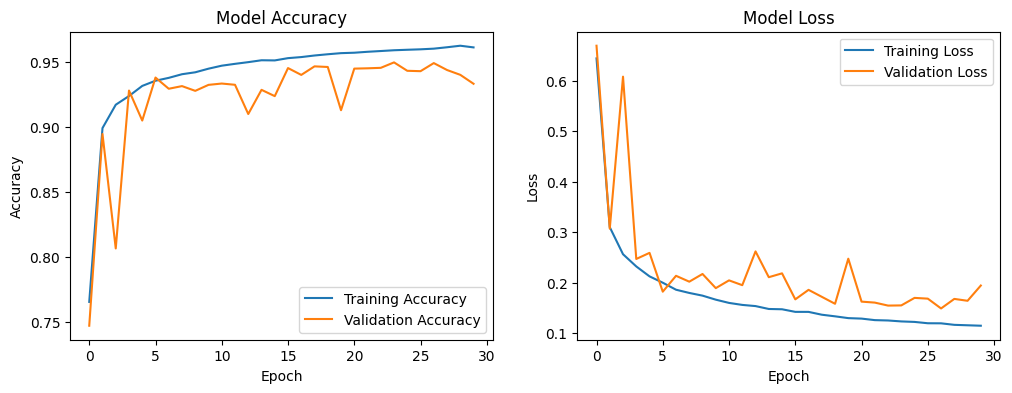


Model training and evaluation complete.


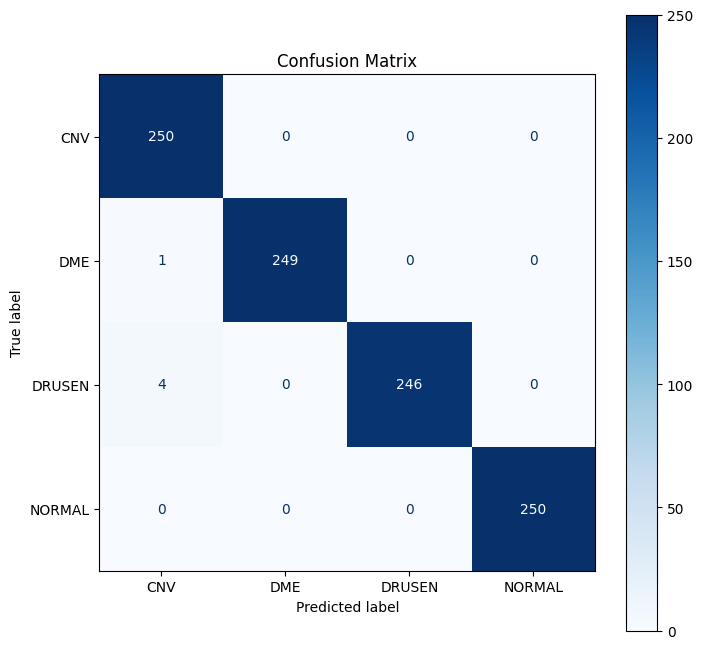


--- Classification Report (Macro Averages) ---
              precision    recall  f1-score   support

         CNV     0.9804    1.0000    0.9901       250
         DME     1.0000    0.9960    0.9980       250
      DRUSEN     1.0000    0.9840    0.9919       250
      NORMAL     1.0000    1.0000    1.0000       250

    accuracy                         0.9950      1000
   macro avg     0.9951    0.9950    0.9950      1000
weighted avg     0.9951    0.9950    0.9950      1000


Overall Test Accuracy: 0.9950
Overall Test Loss: 0.0171


In [6]:
#@title **EVALUATION VISUALIZATION**
test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1) # Use image data here
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# --- Optional: Plot training history ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("\nModel training and evaluation complete.")

import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# === Collect true labels and predicted labels from test_ds ===
y_true_labels = []
y_pred_labels = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred_labels.extend(np.argmax(preds, axis=1))
    y_true_labels.extend(np.argmax(labels.numpy(), axis=1))  # labels are one-hot encoded

y_true_labels = np.array(y_true_labels)
y_pred_labels = np.array(y_pred_labels)

# === Define class names (must match train_ds.class_names order) ===
class_names = ['CNV', 'DME', 'DRUSEN', 'NORMAL']   # Adjust if needed

# === Confusion Matrix ===
cm = confusion_matrix(y_true_labels, y_pred_labels)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Confusion Matrix')
plt.show()

# === Classification Report ===
print("\n--- Classification Report (Macro Averages) ---")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names, digits=4))

# === Optional: Print previously computed test accuracy/loss ===
print(f"\nOverall Test Accuracy: {test_accuracy:.4f}")
print(f"Overall Test Loss: {test_loss:.4f}")

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# === Collect true labels and predicted labels from test_ds ===
y_true_labels = []
y_pred_labels = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred_labels.extend(np.argmax(preds, axis=1))
    y_true_labels.extend(np.argmax(labels.numpy(), axis=1))

# Convert to NumPy arrays
y_true_labels = np.array(y_true_labels)
y_pred_labels = np.array(y_pred_labels)

# === Print classification report ===
class_names = ['CNV', 'DME', 'DRUSEN', 'NORMAL']  # Update if needed
report = classification_report(y_true_labels, y_pred_labels, target_names=class_names, digits=4)
print("\n--- Classification Report ---")
print(report)

# === Print individual metrics ===
accuracy = accuracy_score(y_true_labels, y_pred_labels)
precision = precision_score(y_true_labels, y_pred_labels, average='macro')
recall = recall_score(y_true_labels, y_pred_labels, average='macro')
f1 = f1_score(y_true_labels, y_pred_labels, average='macro')

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")



--- Classification Report ---
              precision    recall  f1-score   support

         CNV     0.9804    1.0000    0.9901       250
         DME     1.0000    0.9960    0.9980       250
      DRUSEN     1.0000    0.9840    0.9919       250
      NORMAL     1.0000    1.0000    1.0000       250

    accuracy                         0.9950      1000
   macro avg     0.9951    0.9950    0.9950      1000
weighted avg     0.9951    0.9950    0.9950      1000


Accuracy:  0.9950
Precision: 0.9951
Recall:    0.9950
F1-Score:  0.9950


✅ Last usable layer for Grad-CAM: re_lu_20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[CNV] → Predicted: CNV (1.00)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 128, 128, 1))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[DME] → Predicted: DME (1.00)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 128, 128, 1))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[DRUSEN] → Predicted: DRUSEN (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[NORMAL] → Predicted: NORMAL (1.00)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 128, 128, 1))
  warnings.warn(msg)


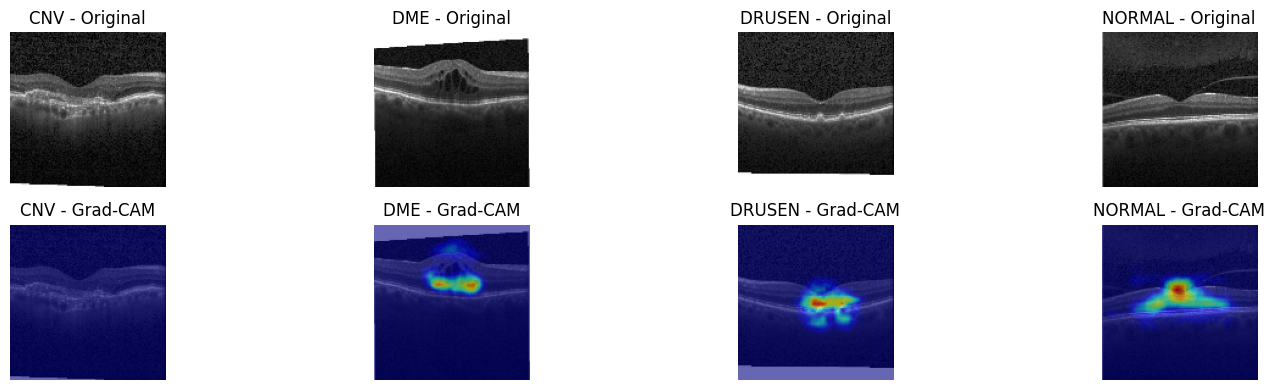

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import matplotlib as mpl
from IPython.display import Image, display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf



import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from tensorflow import keras

# === CONFIG ===


def find_last_conv_or_relu_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D) or isinstance(layer, tf.keras.layers.ReLU):
            print(f"✅ Last usable layer for Grad-CAM: {layer.name}")
            return layer.name
    raise ValueError("No Conv2D or ReLU layer found in model.")





IMG_SIZE = (128, 128)
LAST_CONV_LAYER_NAME = find_last_conv_or_relu_layer(best_model)
OUTPUT_DIR = "/content/gradcam_custom_testds"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# === Generate Grad-CAM heatmap ===
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_output = preds[:, pred_index]

    grads = tape.gradient(class_output, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-6)
    return heatmap.numpy()

# === Overlay heatmap on image ===
def overlay_heatmap(img, heatmap, alpha=0.6):
    if img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)
    img = img.astype("float32") / 255.0

    heatmap = tf.image.resize(tf.expand_dims(heatmap, -1), size=img.shape[:2]).numpy().squeeze()
    heatmap = np.uint8(255 * heatmap)
    jet = mpl.colormaps['jet']
    jet_colors = jet(np.arange(256))[:, :3]
    heatmap_colored = jet_colors[heatmap]

    overlay = heatmap_colored * alpha + img * (1 - alpha)
    return np.clip(overlay, 0, 1)

# === One sample per class from test_ds ===
seen_classes = set()
visuals = []

for images, labels in test_ds:
    preds = best_model.predict(images)
    for i in range(images.shape[0]):
        true_class = tf.argmax(labels[i]).numpy()
        if true_class in seen_classes:
            continue

        img_array = tf.expand_dims(images[i], axis=0)
        pred_class = np.argmax(preds[i])
        confidence = preds[i][pred_class]
        class_name = class_names[true_class]
        pred_label = class_names[pred_class]

        print(f"[{class_name}] → Predicted: {pred_label} ({confidence:.2f})")

        heatmap = make_gradcam_heatmap(img_array, best_model, LAST_CONV_LAYER_NAME, pred_index=pred_class)

        original_img = images[i].numpy()
        cam_overlay = overlay_heatmap(original_img, heatmap)

        # Save
        input_path = os.path.join(OUTPUT_DIR, f"{class_name}_input.png")
        cam_path = os.path.join(OUTPUT_DIR, f"{class_name}_gradcam.png")
        keras.utils.save_img(input_path, original_img, scale=True)
        keras.utils.save_img(cam_path, cam_overlay, scale=True)

        visuals.append((class_name, original_img, cam_overlay))
        seen_classes.add(true_class)

    if len(seen_classes) == len(class_names):
        break

# === Display
plt.figure(figsize=(16, 4))
for i, (class_name, original, cam) in enumerate(visuals):
    plt.subplot(2, len(visuals), i + 1)
    plt.imshow(original.squeeze(), cmap="gray")
    plt.title(f"{class_name} - Original")
    plt.axis("off")

    plt.subplot(2, len(visuals), len(visuals) + i + 1)
    plt.imshow(cam)
    plt.title(f"{class_name} - Grad-CAM")
    plt.axis("off")

plt.tight_layout()
plt.show()
